# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [3]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [5]:
# YOUR CODE HERE
base = "https://dlsun.github.io/pods/data/ml-1m/"
movies_url = base + "movies.dat"
movies_df = pd.read_csv(movies_url,sep="::",
encoding_errors="ignore",
header = None, names= ["movies_id","title","genre"])
movies_df.head()

<positron-console-cell-5>:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,movies_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
base = "https://dlsun.github.io/pods/data/ml-1m/"
ratings_url = base + "ratings.dat"
ratings_df = pd.read_csv(ratings_url,sep="::",
encoding_errors="ignore",
header = None, names= ["user_id","movies_id","ratings","timestamp"])
ratings_df.head()

<positron-console-cell-6>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,movies_id,ratings,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [7]:
base = "https://dlsun.github.io/pods/data/ml-1m/"
users_url = base + "users.dat"
users_df = pd.read_csv(users_url,sep="::",
encoding_errors="ignore",
header = None, names= ["user_id","gender","age","occupation","zip"])
users_df.head()

<positron-console-cell-7>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [8]:
# YOUR CODE HERE
rating_users_df = ratings_df.merge(users_df, on="user_id", how="left", validate="many_to_one")

age_labels = {
    1: "Under 18",
    18: "18–24",
    25: "25–34",
    35: "35–44",
    45: "45–49",
    50: "50–55",
    56: "56+"
}

rating_users_df["age_group"] = rating_users_df["age"].map(age_labels)


(rating_users_df.groupby("age_group")["ratings"]
.agg(n_rating = "size", mean_rating = "mean")
.sort_values("mean_rating", ascending=False)
.reset_index()
)

,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50–55,72490,3.714512
2,45–49,83633,3.638062
3,35–44,199003,3.618162
4,Under 18,27211,3.549520
5,25–34,395556,3.545235
6,18–24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [9]:
# YOUR CODE HERE
movie_summary = (
    ratings_df
    .groupby("movies_id")["ratings"]
    .agg(n_ratings="size", mean_rating="mean")
    .reset_index()
)

movie_summary = movie_summary.merge(
    movies_df,
    on="movies_id",
    how="left",
    validate="many_to_one"
)

qualified_movies = movie_summary[movie_summary["n_ratings"] >= 100]

highest_rated = qualified_movies.sort_values("mean_rating", ascending=False).head(1)
lowest_rated = qualified_movies.sort_values("mean_rating").head(1)

highest_rated[["title", "n_ratings", "mean_rating"]], lowest_rated[["title", "n_ratings", "mean_rating"]]

(                                                  title  n_ratings  \
 1839  Seven Samurai (The Magnificent Seven) (Shichin...        628   
 
       mean_rating  
 1839      4.56051  ,
              title  n_ratings  mean_rating
 764  Kazaam (1996)        120     1.466667)

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [10]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

In [11]:
ratings_with_users_df = ratings_df.merge(
    users_df,
    on="user_id",
    how="left",
    validate="many_to_one"
)

ratings_with_users_df["is_age_18_24"] = (
    ratings_with_users_df["age"] == 18
)

movie_age_summary = (
    ratings_with_users_df
    .groupby("movies_id")
    .agg(
        mean_rating=("ratings", "mean"),
        share_age_18_24=("is_age_18_24", "mean"),
        n_ratings=("ratings", "size")
    )
    .reset_index()
)

movie_age_summary.head()

,movies_id,mean_rating,share_age_18_24,n_ratings
0,1,4.146846,0.215696,2077
1,2,3.201141,0.219686,701
2,3,3.016736,0.223849,478
3,4,2.729412,0.229412,170
4,5,3.006757,0.219595,296


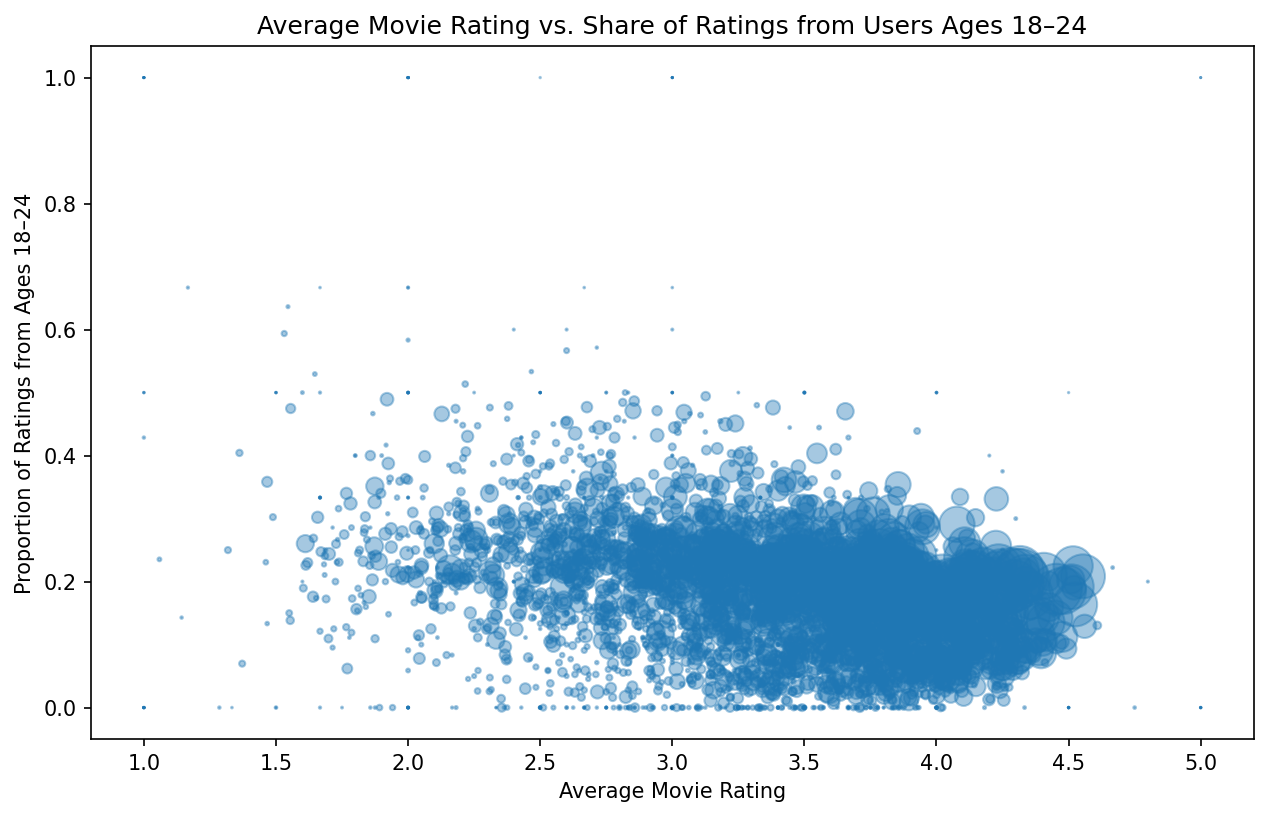

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    movie_age_summary["mean_rating"],
    movie_age_summary["share_age_18_24"],
    s=movie_age_summary["n_ratings"] / 5,
    alpha=0.4
)

plt.xlabel("Average Movie Rating")
plt.ylabel("Proportion of Ratings from Ages 18–24")
plt.title("Average Movie Rating vs. Share of Ratings from Users Ages 18–24")
plt.show()

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [13]:
# YOUR CODE HERE
movie_ratings_df = movies_df.merge(
    ratings_df,
    on="movies_id",
    how="left",
    validate="one_to_many"
)

ratings_by_movie = (
    movie_ratings_df
    .groupby(["movies_id", "title"])["ratings"]
    .count()
    .reset_index(name="number_of_ratings")
)

ratings_by_movie

,movies_id,title,number_of_ratings
0,1,Toy Story (1995),2077
1,2,Jumanji (1995),701
2,3,Grumpier Old Men (1995),478
3,4,Waiting to Exhale (1995),170
4,5,Father of the Bride Part II (1995),296
...,...,...,...
3878,3948,Meet the Parents (2000),862
3879,3949,Requiem for a Dream (2000),304
3880,3950,Tigerland (2000),54
3881,3951,Two Family House (2000),40


In [14]:
ratings_by_movie.query("number_of_ratings == 0").shape[0]

177

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [15]:
# YOUR CODE HERE
one_star = (
    ratings_df[ratings_df["ratings"] == 1]
    .groupby("movies_id")
    .size()
    .reset_index(name="n_1_star")
)

five_star = (
    ratings_df[ratings_df["ratings"] == 5]
    .groupby("movies_id")
    .size()
    .reset_index(name="n_5_star")
)

both_one_and_five = (
    one_star
    .merge(five_star, on="movies_id", how="inner")
    .merge(movies_df[["movies_id", "title"]], on="movies_id", how="left")
    [["movies_id", "title", "n_1_star", "n_5_star"]]
    .sort_values("title")
)

both_one_and_five

,movies_id,title,n_1_star,n_5_star
1472,2031,"$1,000,000 Duck (1971)",3,4
2353,3112,'Night Mother (1986),4,13
572,779,'Til There Was You (1997),5,2
1511,2072,"'burbs, The (1989)",36,23
2561,3420,...And Justice for All (1979),2,38
...,...,...,...,...
1600,2165,Your Friends and Neighbors (1998),9,17
2432,3223,"Zed & Two Noughts, A (1985)",2,3
1322,1845,Zero Effect (1998),7,82
1057,1426,Zeus and Roxanne (1997),5,1


In [16]:
len(both_one_and_five)

2986